# Diverse Dermatology Image Classification - Convolutional Neural Network

By Jade Webb

Dataset: Diverse Dermatology Images Dataset by Stanford University https://ddi-dataset.github.io/

CNN code adapted from CNN.ipynb by Dr. Fabio Di Troia fabio.ditroia@sjsu.edu

Goal: classify samples of dermatology images of patients with darker skin tones as benign or malignant, to support identification of malignant lesions on people of color.

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import tensorflow as tf
from tensorflow.keras import (
    datasets,
    layers,
    models,
    utils,
    regularizers
)
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Constants

In [ ]:
IMAGE_SIZE = 256
TRAIN_SPLIT = 0.7
BATCH_SIZE = 108
L2_REG = 0.0005
DROPOUT_RATE = 0.2

## Display Funtion

In [ ]:
# Displays n random images from each one of the supplied arrays.
def display(
    images, n=10, size=(20, 3), cmap="gray_r", as_type="float32", save_to=None
):
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    for i in range(n):
        _ = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")

    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")

    plt.show()

## Load Diverse Dermatology Metadata

In [ ]:
# Load metadata
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DDI/ddidiversedermatologyimages/ddi_metadata.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
df

,DDI_ID,DDI_file,skin_tone,malignant,disease
0,1,000001.png,56,True,melanoma-in-situ
1,2,000002.png,56,True,melanoma-in-situ
2,3,000003.png,56,True,mycosis-fungoides
3,4,000004.png,56,True,squamous-cell-carcinoma-in-situ
4,5,000005.png,12,True,basal-cell-carcinoma
...,...,...,...,...,...
651,652,000652.png,34,False,pyogenic-granuloma
652,653,000653.png,34,False,melanocytic-nevi
653,654,000654.png,34,False,acral-melanotic-macule
654,655,000655.png,34,True,squamous-cell-carcinoma


In [ ]:
# Get malignant labels
malignant = df['malignant']

# Map malignancy classes to numbers
unique_malignant = malignant.unique().tolist()
malignant_to_int = {malignant: i for i, malignant in enumerate(unique_malignant)}

NUM_CLASSES = len(unique_malignant)

# Create dataset from dictionary
df_dataset = tf.data.Dataset.from_tensor_slices(malignant.map(malignant_to_int).values)

## Load Diverse Dermatology Dataset Images

In [ ]:
# Load images into a dataset
ddi = utils.image_dataset_from_directory(
    "/content/drive/MyDrive/Colab Notebooks/DDI/ddidiversedermatologyimages/",
    labels=None,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=None,
    shuffle=False,
    interpolation="bilinear",
)

Found 656 files.


In [ ]:
ddi

<_PrefetchDataset element_spec=TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None)>

## Visualize Dataset Sample

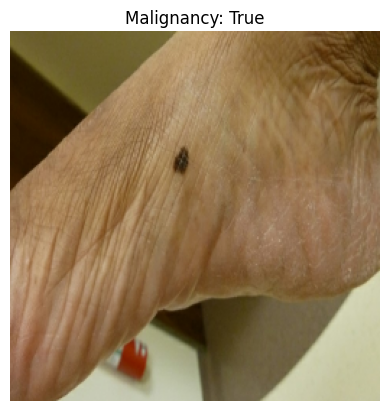

In [ ]:
for row in ddi.take(1):
    plt.imshow(row.numpy().astype("uint8"))
    for label in df_dataset.take(1):
      malignant = unique_malignant[label.numpy()]
      plt.title("Malignancy: " + str(malignant))
    plt.axis("off")

## Combine Image and Label Datasets

In [ ]:
dataset = tf.data.Dataset.zip((ddi, df_dataset))

## Shuffling

In [ ]:
dataset = dataset.shuffle(buffer_size=dataset.cardinality(), seed=42)

## Train Validation Test Split

In [ ]:
train_size = int(TRAIN_SPLIT * ddi.cardinality().numpy())
val_test_size = (ddi.cardinality().numpy() - train_size) / 2

In [ ]:
train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size)
val_dataset = val_dataset.take(val_test_size)
test_dataset = dataset.skip(train_size)
test_dataset = test_dataset.skip(val_test_size)
test_dataset = test_dataset.take(val_test_size)

## Preprocess Images

In [ ]:
# Image augmentation
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.2)
])

# Preprocess images with augmentation
def preprocess_and_augment(img, label):
    img = tf.cast(img, "float32") / 255.0
    img = data_augmentation(img, training=True)
    return img, label

# Preprocess images
def preprocess(img, label):
    img = tf.cast(img, "float32") / 255.0
    return img, label

train_dataset = train_dataset.map(preprocess_and_augment)
val_dataset = val_dataset.map(preprocess)
test_dataset = test_dataset.map(preprocess)

## Batching

In [ ]:
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## Model Definition

### Convolutional Base

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
                        kernel_regularizer=regularizers.l2(L2_REG)))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(layers.Dropout(DROPOUT_RATE))

model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), activation='relu',
                        kernel_regularizer=regularizers.l2(L2_REG)))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(layers.Dropout(DROPOUT_RATE))

model.add(layers.Conv2D(filters=96, kernel_size=(3, 3), strides=(1, 1), activation='relu',
                        kernel_regularizer=regularizers.l2(L2_REG)))
model.add(layers.Dropout(DROPOUT_RATE))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Dense Layers

In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu',
                       kernel_regularizer=regularizers.l2(L2_REG)))
model.add(layers.Dropout(DROPOUT_RATE))

model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

### Model Architecture

In [ ]:
model.summary()

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 60, 60, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 60, 60, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 345600)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │    44,236,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_59 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,311,970 (169.04 MB)

 Trainable params: 44,311,970 (169.04 MB)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [ ]:
model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(train_dataset, epochs=50,
                    validation_data=(val_dataset), callbacks=[early_stopping])

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/nn.py:708: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5276 - loss: 10.2242 - val_accuracy: 0.2755 - val_loss: 1.1557
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.3291 - loss: 1.2717 - val_accuracy: 0.7041 - val_loss: 1.0296
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5121 - loss: 1.0436 - val_accuracy: 0.7041 - val_loss: 1.0510
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7512 - loss: 1.0065 - val_accuracy: 0.7857 - val_loss: 0.9707
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7438 - loss: 0.9894 - val_accuracy: 0.7449 - val_loss: 1.0022
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7434 - loss: 0.9848 - val_accuracy: 0.7041 - val_loss: 1.0226


## Visualize Performance

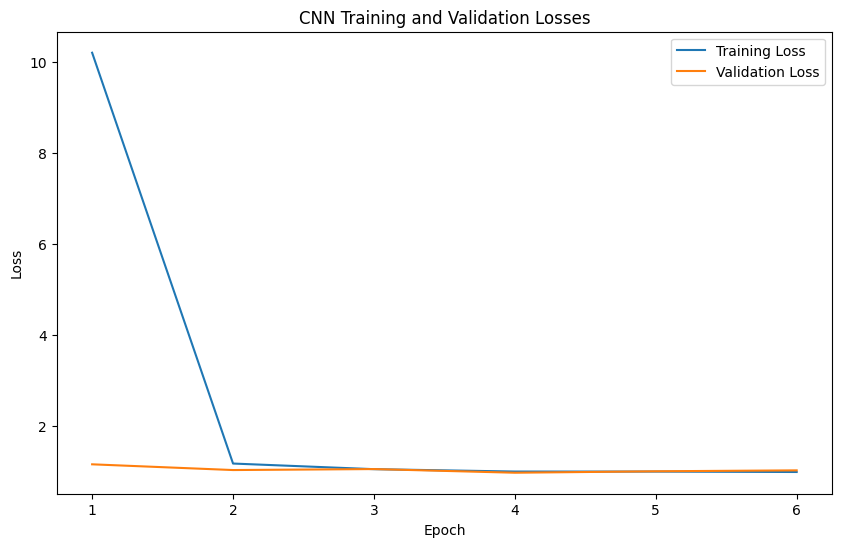

In [ ]:
# Plot losses over time
train_losses = history.history['loss']
val_losses = history.history['val_loss']
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.arange(1, len(train_losses) + 1), train_losses, label="Training Loss")
ax.plot(np.arange(1, len(val_losses) + 1), val_losses, label="Validation Loss")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.title('CNN Training and Validation Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

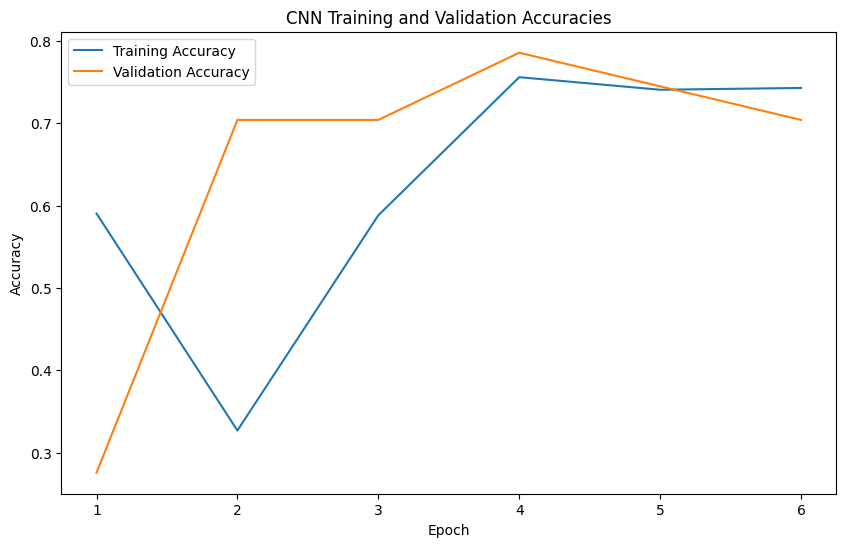

In [ ]:
# Plot accuracies over time
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.arange(1, len(train_accuracy) + 1), train_accuracy, label='Training Accuracy')
ax.plot(np.arange(1, len(val_accuracy) + 1), val_accuracy, label='Validation Accuracy')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.title('CNN Training and Validation Accuracies')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Model Testing

In [ ]:
# Classify test set
test_loss, test_acc = model.evaluate(test_dataset, verbose=2)

1/1 - 2s - 2s/step - accuracy: 0.7755 - loss: 0.9780
